5️⃣ SEPARATION  TRAIN/TEST

In [1]:
#importation des données
import pandas as pd
df = pd.read_excel('Dataset2_traite.iqa.xlsx')


#separation des features et de la cible
X = df.drop(columns=['target_iqa'])
y = df['target_iqa']



#separation des données en train et test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#importation des modele de regression
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.ensemble import BaggingRegressor
from sklearn.ensemble import StackingRegressor


6️⃣/7️⃣  ENTAINEMENT DU MODELE  -  EVALUATION 


In [2]:
#initialisation des modele de regression
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(),
    'Support Vector Regressor': SVR(),
    'K-Nearest Neighbors': KNeighborsRegressor(),
    'Decision Tree': DecisionTreeRegressor(),
    'Gradient Boosting': GradientBoostingRegressor(),
    'AdaBoost': AdaBoostRegressor(),
    'Extra Trees': ExtraTreesRegressor(),
    'Bagging': BaggingRegressor(),
    'Stacking': StackingRegressor(estimators=[
        ('rf', RandomForestRegressor()),
        ('gb', GradientBoostingRegressor()),
        ('dt', DecisionTreeRegressor())
    ], final_estimator=LinearRegression())
}



#entrainement des modele de regression
for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"{name} entrainé avec succès.")

#evaluation des modele de regression et stockage des résultats dans un dataframe
from sklearn.metrics import mean_squared_error, r2_score
results = []
for name, model in models.items():
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    results.append({'Model': name, 'MSE': mse, 'R2': r2})

    
results_df = pd.DataFrame(results)


Linear Regression entrainé avec succès.
Random Forest entrainé avec succès.
Support Vector Regressor entrainé avec succès.
K-Nearest Neighbors entrainé avec succès.
Decision Tree entrainé avec succès.
Gradient Boosting entrainé avec succès.
AdaBoost entrainé avec succès.
Extra Trees entrainé avec succès.
Bagging entrainé avec succès.
Stacking entrainé avec succès.


In [3]:
#affichage des résultats
results_df.sort_values(by='R2', ascending=False, inplace=True)
print(results_df)

                      Model       MSE        R2
9                  Stacking  0.000712  0.947262
5         Gradient Boosting  0.000737  0.945384
1             Random Forest  0.000739  0.945243
7               Extra Trees  0.000767  0.943151
8                   Bagging  0.000808  0.940168
0         Linear Regression  0.000834  0.938229
3       K-Nearest Neighbors  0.001006  0.925435
6                  AdaBoost  0.001420  0.894788
4             Decision Tree  0.001475  0.890729
2  Support Vector Regressor  0.001556  0.884755


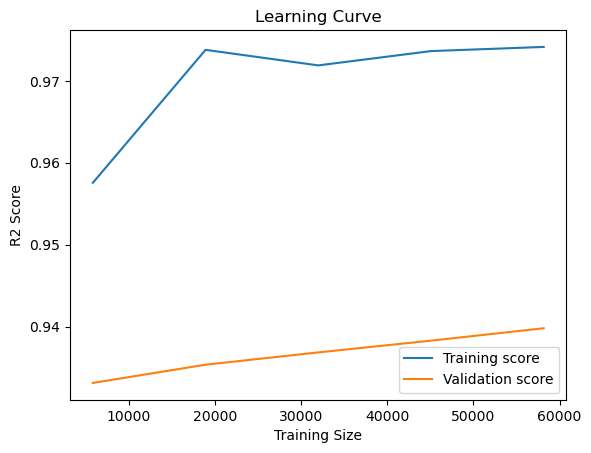

Exception ignored in: <function ResourceTracker.__del__ at 0x7f321fc52b60>
Traceback (most recent call last):
  File "/home/foyem-yvan/anaconda3/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/home/foyem-yvan/anaconda3/lib/python3.12/multiprocessing/resource_tracker.py", line 86, in _stop
  File "/home/foyem-yvan/anaconda3/lib/python3.12/multiprocessing/resource_tracker.py", line 111, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x7b526dc4eb60>
Traceback (most recent call last):
  File "/home/foyem-yvan/anaconda3/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/home/foyem-yvan/anaconda3/lib/python3.12/multiprocessing/resource_tracker.py", line 86, in _stop
  File "/home/foyem-yvan/anaconda3/lib/python3.12/multiprocessing/resource_tracker.py", line 111, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <fun

In [ ]:
#courbe d'apprentissage pour le meilleur modèle
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# calcul des learning curves
train_sizes, train_scores, val_scores = learning_curve(
    StackingRegressor(
        estimators=[
            ('rf', RandomForestRegressor(n_estimators=50)),
            ('gb', GradientBoostingRegressor(n_estimators=50)),
            ('dt', DecisionTreeRegressor())
        ],
        final_estimator=LinearRegression()
    ),
    X, y,
    cv=3,
    scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 5),
    n_jobs=-1
)
# moyenne des scores
train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

# tracé
plt.figure()
plt.plot(train_sizes, train_mean, label="Training score")
plt.plot(train_sizes, val_mean, label="Validation score")

plt.xlabel("Training Size")
plt.ylabel("R2 Score")
plt.title("Learning Curve")
plt.legend()

plt.show()
